# Eigenvalues, eigenvectors and covariance


## 1. Retrieval

Answer without notes:

1. What does it mean for two non-zero vectors to be orthogonal?

> Orthogonal vectors have a dot product = 0 and their spans are perpendicular to one another

2. How do you normalise a vector?

> Divide the vector by its magnitude: $\hat{u}=\frac{u}{||u||}$

3. What does the vector projection of a onto b represent?

> The component of `a` along the line spanned by `b`

4. What is the residual after projection?

> The part of `a` not captured by the projection. The residual of `a` when projecting onto `b` is othogonal to `b`

5. Why does a projection matrix satisfy P @ P = P?

> Once a vector has been projected it already lies in the target subspace, meaning reapplying the same projection transformation has no further effect.

6. What does rank tell you about the dimension of a matrix’s output space?

> A rank of `n` means the matrix's output space has dimension `n`

7. What does determinant zero tell you about invertibility?

> Determinant = 0 tells you the matrix does not have an inverse

## 2. Learn

3Blue1Brown, Essence of linear algebra

- [Chapter 13, Eigenvectors and eigenvalues](https://www.youtube.com/watch?v=PFDu9oVAE-g&pp=ugUHEgVlbi1VUw%3D%3D)

### Eigenvectors

Normally, multiplying a vector by a matrix can change both its direction and magnitude: $Av$

An **eigenvector** is a specialnon-zero vector whose direction is unchanged by the transformation. Instead it is only scaled:

$$ Av=λv $$

where:
- $v$ is the eigenvector;
- λ is its eigenvalue.

### Eigenvalues
The eigenvalues tells you the scaling applied along the eigenvector directions. Interpretation:
- λ > 1: stratched;
- 0 < λ < 1: compressed;
- λ < 0: direction reversed as well as scaled;
- λ = 0: collapsed to the zero vector.

### NumPy

Numpy provides:

`eigenvalues, eigenvectors = np.linalg.eig(A)`

There is one important convection here:

**Eigenvectors are returned as the columns of `eigenvectors`**

So `eigenvectors[:,0]` corresponds to the eigenvalues at `eigenvalues[0]`


## 3. First eigenvector experiment

Use:

In [1]:
import numpy as np

A = np.array([
    [3, 1],
    [0, 2]
])

Before using np.linalg.eig(), try these candidate vectors:

In [2]:
v1 = np.array([1, 0])
v2 = np.array([1, -1])
v3 = np.array([1, 1])

For each vector:

1. calculate A @ v;
2. decide whether the result is a scalar multiple of the original vector;
3. if it is, identify the scaling factor.

Record your reasoning before asking NumPy for the eigenvalues.

In [3]:
x1 = A @ v1
print('A @ v1 =', x1)
# x1 = [3, 0] -> 3 * v1 (3x scalar multiple)

A @ v1 = [3 0]


In [4]:
x2 = A @ v2
print('A @ v2 =', x2)
# x2 = [2, -2] -> 2 * v2 (2x scalar multiple)

A @ v2 = [ 2 -2]


In [5]:
x3 = A @ v3
print('A @ v3 =',x3)
# x3 = [4, 2] -> not on the line spanned by v3

A @ v3 = [4 2]


Then run:

`eigenvalues, eigenvectors = np.linalg.eig(A)`

Inspect:

`eigenvalues`
`eigenvectors`

For each returned pair, verify:

`A @ v`

against:

`lambda_value * v`

using `np.allclose()`.


In [6]:
eigenvalues, eigenvectors = np.linalg.eig(A)
print('Eigenvalues:', eigenvalues)
print('Eigenvectors:\n', eigenvectors)

Eigenvalues: [3.+0.j 2.+0.j]
Eigenvectors:
 [[ 1.        +0.j -0.70710678+0.j]
 [ 0.        +0.j  0.70710678+0.j]]


In [7]:
print('A @ ev1 == lamda_1 * ev1:', np.allclose(A @ eigenvectors[:,0], eigenvalues[0] * eigenvectors[:,0]))
print('A @ ev2 == lamda_2 * ev2:', np.allclose(A @ eigenvectors[:,1], eigenvalues[1] * eigenvectors[:,1]))

A @ ev1 == lamda_1 * ev1: True
A @ ev2 == lamda_2 * ev2: True


## 4. Interpret eigenvalues geometrically

Use:

In [8]:
B = np.array([
    [2, 0],
    [0, 0.5]
])

Before running anything, predict:

1. one likely eigenvector direction;

> [1, 0]

2. another likely eigenvector direction;

> [0, 1]

3. the scaling associated with each.

> $2, \frac{1}{2}$

Then calculate the eigenvalues and eigenvectors.

In [9]:
eigenvalues_B, eigenvectors_B = np.linalg.eig(B)
print(eigenvectors_B)

[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]


Answer:

1. Which direction is stretched most?

> x axis ([1, 0]) is strecthed the most

2. Which direction is compressed?

> y axis ([0, 1]) is compressed

3. Does the transformation rotate either eigenvector?

> Transformation doesn't rotate, only scales

4. What happens to vectors that are not aligned with an eigenvector?

> The transformation maps it outside its original span.

## 5. Covariance — learn

Moving from transformations to datasets.

Suppose you have two variables:
- $x$
- $y$

Covariance measures whether they tend to vary together. For **sample covariance**:

$$cov(x,y)=\frac{1}{n-1} \displaystyle\sum_{i=1}^n (x_i-\bar{x})(y_i-\bar{y})$$

Interpretation:
- positive covariance $\rarr$ high values of one tend to occur with high values of the other;
- negative covariance $\rarr$ high values of one tend to occur with low values of the other;
- covariance near zero $\rarr$ little linear co-variance

The magnitude depends on the units of the variables, so unlike correlation it is not automatically bounded between -1 and 1

### Covariance matrix

For a dataset with two variables:

$$\Sigma = \begin{bmatrix} var(x)&cov(x,y) \cr cov(x,y)&var(y)\end{bmatrix}$$

Notice:
- the diagonal contains variances;
- the off-diagonal entries contain covariances;
- the covariance matrix is symmetric.

**This symmetry becomes important for principal component analysis**

## 6. Calculate covariance manually

Use:

In [10]:
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 8, 11])

Calculate manually with NumPy operations:

1. mean_x
2. mean_y
3. centred x
4. centred y
5. elementwise products of the centred values
6. sample covariance

Do not use np.cov() initially.

In [11]:
mean_x = np.mean(x)
mean_y = np.mean(y)

centered_x = x - mean_x
centered_y = y - mean_y

centered_products = centered_x * centered_y

manual_covariance = 1 / (len(x) - 1) * centered_products.sum()

print(manual_covariance)

# Verify with np.cov(x, y)

cov_matrix = np.cov(x, y)
var_x = cov_matrix[0,0]
var_y = cov_matrix[1,1]
covariance = cov_matrix[1,0]

print('Manual covariance == np.cov covariance:', np.allclose(manual_covariance, covariance))



5.5
Manual covariance == np.cov covariance: True


The two off-diagonal values are equal because the covariance matrix is symmetric and the off-diagnonal values both calculate covariance. One calculates as $cov(x,y)$ and the other as $cov(y,x)$, however these two values are the same

## 7. Covariance from an observation matrix

Use:

In [12]:
data = np.array([
    [1, 2],
    [2, 4],
    [3, 5],
    [4, 8],
    [5, 11]
])

Here:

- rows = observations;
- columns = variables.

Calculate the mean of each feature:

`feature_means = ...`

Then centre the dataset:

`centred_data = ...`

Verify that the mean of each centred column is approximately zero.

In [13]:
# Feature means
feature_means = data.mean(axis=0)
centered_data = data - feature_means

print('Mean of centered columns is approximateley zero:', np.allclose(centered_data.mean(axis=0), 0))

Mean of centered columns is approximateley zero: True


Now calculate:

`cov_matrix = np.cov(data, rowvar=False)`

The rowvar=False argument tells NumPy:

- rows are observations and columns are variables.

That convention is worth writing down because it will matter in the PCA project.

In [14]:
cov_matrix = np.cov(centered_data, rowvar=False)
print('Covariance matrix:\n',cov_matrix)

Covariance matrix:
 [[ 2.5  5.5]
 [ 5.5 12.5]]


## 8. Connect covariance to eigenvectors

Take your covariance matrix and calculate:

In [15]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print('cov_matrix eigenvalues:', eigenvalues)
print('cov_matrix eigenvectors:\n', eigenvectors)

cov_matrix eigenvalues: [ 0.06696563+0.j 14.93303437+0.j]
cov_matrix eigenvectors:
 [[-0.9145143 +0.j -0.40455358+0.j]
 [ 0.40455358+0.j -0.9145143 +0.j]]


Answer:

1. How many eigenvalues are there?

> 2 eigenvalues

2. How many eigenvectors?

> 2 eigenvectors

3. Which eigenvalue is larger?

> `eigenvalues[1]` is larger than `eigenvalues[0]`: 14.93 > 0.06

4. Which eigenvector corresponds to the larger eigenvalue?

> `eigenvector[:,1]` corresponds to the larger eigenvalue: [-0.40, -0.91]

5. What direction does that vector appear to point through the dataset?

> diagonally down to the left



Verify:

`cov_matrix @ eigenvectors[:, 0]`

against:

`eigenvalues[0] * eigenvectors[:, 0]`

and repeat for the second pair.

In [16]:
print('cov_matrix @ ev1 == lamda_1 * ev1:', np.allclose(cov_matrix @ eigenvectors[:,0], eigenvalues[0] * eigenvectors[:,0]))
print('cov_matrix @ ev2 == lamda_2 * ev2:', np.allclose(cov_matrix @ eigenvectors[:,1], eigenvalues[1] * eigenvectors[:,1]))

cov_matrix @ ev1 == lamda_1 * ev1: True
cov_matrix @ ev2 == lamda_2 * ev2: True


## 9. Visualisation extension

Plot the centred observations:

```
centred_data[:, 0]
centred_data[:, 1]
```

Then draw the two eigenvector directions through the origin.

A useful way to scale the arrows for visibility is:

```
direction = eigenvectors[:, i]
scale = np.sqrt(eigenvalues[i])
```

and draw something proportional to:


```scale * direction```

The exact plotting syntax is not the learning target, so documentation is fine.

Under the plot, explain:

- which eigenvector follows the dominant direction of variation;
- why its eigenvalue is larger;
- what the smaller eigenvector represents.

c:\Users\Rory\Documents\3. Coding\msc-ai-prep\.venv\Lib\site-packages\matplotlib\transforms.py:1913: ComplexWarning: Casting complex values to real discards the imaginary part
  return affine_transform(values, mtx)


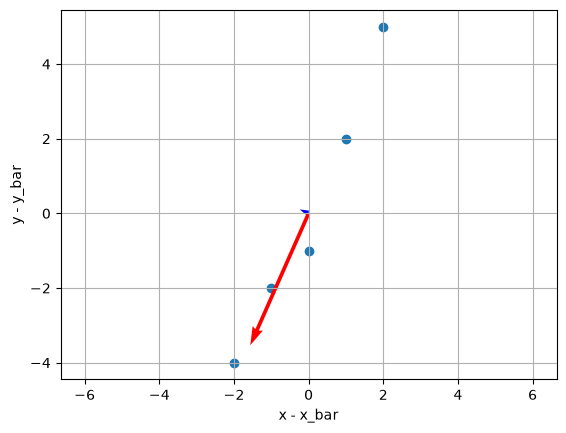

In [17]:
import matplotlib.pyplot as plt

scales = np.sqrt(eigenvalues)
scaled_v = eigenvectors * scales

fig, ax = plt.subplots()

ax.scatter(
  centered_x,
  centered_y,
  label='Centered data'
)

ax.quiver(
  [0, 0],                 # starting x positions
  [0, 0],                 # starting y positions
  scaled_v[0,:],          # x-components
  scaled_v[1,:],          # y-components
  color=['b','r'],
  angles='xy',
  scale_units='xy',
  scale=1,
)

plt.grid(visible=True)
ax.axis('equal')
ax.set_title('')
ax.set_xlabel('x - x_bar')
ax.set_ylabel('y - y_bar')

plt.show()

Explain:

- which eigenvector follows the dominant direction of variation;

> The eigenvector with the larger corresponding eigenvalue follows the direction of variation

- why its eigenvalue is larger;

> The eigenvalue measures the amount of variance in the dataset along the eigenvector direction. In this dataset we see the data is spread a lot along the eigenvector corresponding with the larger eigenvalue and very little along the direction that the second egenvector points along which has the smaller eigenvalue.

- what the smaller eigenvector represents.

> The larger eigenvector runs along the direction of the data while the small eigenvector runs across it. It's tiny eigenvalue tells you that the points barely vary in the perpendicular direction.

## 10. Reflection

Answer:

1. What makes an eigenvector special?

> Their direction does not change when transformed by the matrix they are associated to

2. What does its eigenvalue represent?

> The scalar applied by the transformation

3. Why can an eigenvalue be negative?

> Because a transformation can flip the orientation of a vector without changing the space that it spans

4. What does covariance measure?

> The extent to which two variables vary together

5. What appears on the diagonal of a covariance matrix?

> $var(x)$ and $var(y)$

6. Why is a covariance matrix symmetric?

> Because $cov(x,y)=cov(y,x)$, so the entries mirrored across the diagonal are equal.

7. What relationship did you observe between the largest covariance-matrix eigenvalue and the direction of the dataset?

> The eigenvector associated with the largest covariance-matrix eigenvalue closely matched the direction of the dataset

8. Which part remains least intuitive?

> What the smaller eigenvector represents, and what dictates the orientation of the eigenvectors since in this dataset the larger eigenvector is pointing in the -x, -y direction when it seems like it could also be pointing in the x, y direction given the dataset

> Correction: The larger eigenvalue identifies the direction with the greatest variance in the dataset, while the smaller eigenvalue identifies the orthogonal direction with much less variance. An eigenvector's sign is arbitrary, so [x, y] and [-x, -y] represent the same eigenvector axis.